# ✅ BALANCED FER Model - Based on Research Papers

## Problem Analysis:
- **First attempt:** 24% (too complex + conflicts)
- **Second attempt:** 51% (too simple, underfitting)
- **This version:** Balanced middle ground

## Based On:
- Research papers achieving 65-72% on FER2013
- Proven architectures from Kaggle competitions
- No experimental techniques, only proven ones

## Key Changes from Failed Versions:
1. ✅ Moderate capacity (not too big, not too small)
2. ✅ Proven learning rate schedule
3. ✅ Balanced regularization
4. ✅ Proper data preprocessing
5. ✅ No conflicting techniques

---

## 1. Imports

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import cv2
import time
from datetime import datetime

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential, Model, load_model
from tensorflow.keras.layers import (
    Conv2D, MaxPooling2D, Dense, Dropout, Input,
    BatchNormalization, GlobalAveragePooling2D, Activation
)
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import (
    EarlyStopping, ReduceLROnPlateau, ModelCheckpoint, LearningRateScheduler
)
from tensorflow.keras.regularizers import l2

from sklearn.metrics import (
    classification_report, confusion_matrix,
    precision_recall_fscore_support, accuracy_score
)
from sklearn.utils.class_weight import compute_class_weight

import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)
tf.random.set_seed(42)

print("="*70)
print("✅ BALANCED FER MODEL - PROVEN ARCHITECTURE")
print("="*70)
print(f"TensorFlow: {tf.__version__}")
print(f"GPU: {tf.config.list_physical_devices('GPU')}")
print("="*70)

✅ BALANCED FER MODEL - PROVEN ARCHITECTURE
TensorFlow: 2.19.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## 2. PROVEN Configuration (From Research)

In [ ]:
# =================================================================
# PROVEN SETTINGS - Based on successful FER2013 implementations
# =================================================================

# Paths
BASE_DIR = "/content/FER2013"

# Image settings
IMG_SIZE = 48
CHANNELS = 1

# Training - BALANCED
BATCH_SIZE = 64
EPOCHS = 100

# Learning rate - PROVEN to work
INITIAL_LR = 3e-4  # Sweet spot between 1e-4 and 1e-3
MIN_LR = 1e-7

# Regularization - MODERATE
L2_REG = 5e-5  # Lighter
DROPOUT_CONV = 0.25  # Standard for conv layers
DROPOUT_DENSE = 0.5  # Standard for dense layers

# Early stopping
PATIENCE = 15

EMOTIONS = ['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']
NUM_CLASSES = len(EMOTIONS)

print("⚙️ PROVEN CONFIGURATION")
print("="*50)
print(f"Batch size: {BATCH_SIZE}")
print(f"Initial LR: {INITIAL_LR}")
print(f"L2 reg: {L2_REG}")
print(f"Dropout (conv): {DROPOUT_CONV}")
print(f"Dropout (dense): {DROPOUT_DENSE}")
print("="*50)

⚙️ PROVEN CONFIGURATION
Batch size: 64
Initial LR: 0.0003
L2 reg: 5e-05
Dropout (conv): 0.25
Dropout (dense): 0.5


## 3. Data Loading

In [ ]:
# Mount Google Drive (if using Colab)
try:
    from google.colab import drive
    drive.mount('/content/drive')
    BASE_DIR = "/content/drive/MyDrive/FER2013"
except:
    BASE_DIR = "path/to/your/FER2013"  # Update this path

print(f"Base directory: {BASE_DIR}")
print(f"Contents: {os.listdir(BASE_DIR)}")

Mounted at /content/drive
Base directory: /content/drive/MyDrive/FER2013
Contents: ['test', 'train']


In [ ]:
def load_fer_data(base_dir, verbose=True):
    """
    Load FER2013 with proper preprocessing.
    """
    X, y = [], []
    class_names = sorted(os.listdir(base_dir))

    if verbose:
        print(f"Loading from: {base_dir}")

    for label, emotion in enumerate(class_names):
        folder = os.path.join(base_dir, emotion)
        if not os.path.isdir(folder):
            continue

        image_files = [f for f in os.listdir(folder)
                      if f.endswith(('.jpg', '.jpeg', '.png'))]

        if verbose:
            print(f"  {emotion}: {len(image_files)} images")

        for img_name in image_files:
            try:
                img_path = os.path.join(folder, img_name)
                img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)

                if img is None:
                    continue

                # Resize
                img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))

                # Normalize to [0, 1]
                img = img.astype('float32') / 255.0

                # Add channel
                img = np.expand_dims(img, axis=-1)

                X.append(img)
                y.append(label)

            except:
                continue

    X = np.array(X, dtype=np.float32)
    y = np.array(y, dtype=np.int32)

    if verbose:
        print(f"\n✓ Loaded: {len(X)} images")
        print(f"  Shape: {X.shape}")

    return X, y, class_names

# Load data
print("="*60)
print("LOADING DATA")
print("="*60)

X_train, y_train, class_names = load_fer_data(BASE_DIR + "/train")
X_test, y_test, _ = load_fer_data(BASE_DIR + "/test")

print(f"\nTrain: {X_train.shape}")
print(f"Test: {X_test.shape}")
print("="*60)

LOADING DATA
Loading from: /content/drive/MyDrive/FER2013/train
  angry: 3995 images
  disgust: 436 images
  fear: 4097 images
  happy: 7215 images
  neutral: 4965 images
  sad: 4830 images
  surprise: 3171 images

✓ Loaded: 28709 images
  Shape: (28709, 48, 48, 1)
Loading from: /content/drive/MyDrive/FER2013/test
  angry: 958 images
  disgust: 111 images
  fear: 1024 images
  happy: 1774 images
  neutral: 1248 images
  sad: 1247 images
  surprise: 831 images

✓ Loaded: 7193 images
  Shape: (7193, 48, 48, 1)

Train: (28709, 48, 48, 1)
Test: (7193, 48, 48, 1)


## 4. Class Weights & Labels

In [ ]:
# Class weights
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)
class_weights_dict = dict(enumerate(class_weights))

print("⚖️ CLASS WEIGHTS")
for i, emotion in enumerate(EMOTIONS):
    print(f"  {emotion:10s}: {class_weights[i]:.3f}")

# One-hot encode (NO SMOOTHING)
y_train_cat = keras.utils.to_categorical(y_train, NUM_CLASSES)
y_test_cat = keras.utils.to_categorical(y_test, NUM_CLASSES)

print(f"\n✓ Labels prepared")

⚖️ CLASS WEIGHTS
  angry     : 1.027
  disgust   : 9.407
  fear      : 1.001
  happy     : 0.568
  neutral   : 0.826
  sad       : 0.849
  surprise  : 1.293

✓ Labels prepared


## 5. Data Augmentation (PROVEN Settings)

In [ ]:
# Standard augmentation that works well for faces
train_datagen = ImageDataGenerator(
    rotation_range=10,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True,
    zoom_range=0.1,
    fill_mode='nearest'
)

test_datagen = ImageDataGenerator()

print("🔄 DATA AUGMENTATION")
print("  Rotation: ±10°")
print("  Shifts: 10%")
print("  Zoom: 10%")
print("  Flip: Yes")

🔄 DATA AUGMENTATION
  Rotation: ±10°
  Shifts: 10%
  Zoom: 10%
  Flip: Yes


## 6. Model Architecture (BALANCED)

In [ ]:
def build_balanced_model():
    """
    Balanced VGGNet architecture.

    Based on successful Kaggle implementations:
    - 4 conv blocks with increasing filters
    - BatchNorm for stability
    - Moderate dropout
    - ~3.5M parameters (sweet spot)
    """
    model = Sequential([
        Input(shape=(IMG_SIZE, IMG_SIZE, CHANNELS)),

        # Block 1: 64 filters
        Conv2D(64, (3,3), padding='same', kernel_regularizer=l2(L2_REG)),
        BatchNormalization(),
        Activation('relu'),
        Conv2D(64, (3,3), padding='same', kernel_regularizer=l2(L2_REG)),
        BatchNormalization(),
        Activation('relu'),
        MaxPooling2D((2,2)),
        Dropout(DROPOUT_CONV),

        # Block 2: 128 filters
        Conv2D(128, (3,3), padding='same', kernel_regularizer=l2(L2_REG)),
        BatchNormalization(),
        Activation('relu'),
        Conv2D(128, (3,3), padding='same', kernel_regularizer=l2(L2_REG)),
        BatchNormalization(),
        Activation('relu'),
        MaxPooling2D((2,2)),
        Dropout(DROPOUT_CONV),

        # Block 3: 256 filters
        Conv2D(256, (3,3), padding='same', kernel_regularizer=l2(L2_REG)),
        BatchNormalization(),
        Activation('relu'),
        Conv2D(256, (3,3), padding='same', kernel_regularizer=l2(L2_REG)),
        BatchNormalization(),
        Activation('relu'),
        Conv2D(256, (3,3), padding='same', kernel_regularizer=l2(L2_REG)),
        BatchNormalization(),
        Activation('relu'),
        MaxPooling2D((2,2)),
        Dropout(DROPOUT_CONV),

        # Block 4: 512 filters (INCREASED - we need capacity)
        Conv2D(512, (3,3), padding='same', kernel_regularizer=l2(L2_REG)),
        BatchNormalization(),
        Activation('relu'),
        Conv2D(512, (3,3), padding='same', kernel_regularizer=l2(L2_REG)),
        BatchNormalization(),
        Activation('relu'),
        MaxPooling2D((2,2)),
        Dropout(DROPOUT_CONV),

        # Global pooling
        GlobalAveragePooling2D(),

        # Dense layers
        Dense(512, kernel_regularizer=l2(L2_REG)),
        BatchNormalization(),
        Activation('relu'),
        Dropout(DROPOUT_DENSE),

        Dense(256, kernel_regularizer=l2(L2_REG)),
        BatchNormalization(),
        Activation('relu'),
        Dropout(DROPOUT_DENSE),

        # Output
        Dense(NUM_CLASSES, activation='softmax')
    ])

    return model

# Build
model = build_balanced_model()

print("\n🏗️ MODEL ARCHITECTURE")
print("="*70)
model.summary()
print("="*70)

params = model.count_params()
print(f"\nParameters: {params:,} (~{params/1e6:.1f}M)")
print(f"Model size: ~{params*4/1024/1024:.1f} MB")


🏗️ MODEL ARCHITECTURE


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 48, 48, 64)     │           640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 48, 48, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 48, 48, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 48, 48, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 48, 48, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 48, 48, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 24, 24, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 24, 24, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 24, 24, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 24, 24, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 24, 24, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 24, 24, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 24, 24, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 24, 24, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 12, 12, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 12, 12, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 12, 12, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 12, 12, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_4 (Activation)       │ (None, 12, 12, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 12, 12, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 12, 12, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_5 (Activation)       │ (None, 12, 12, 256)    │             

 Total params: 5,681,863 (21.67 MB)

 Trainable params: 5,675,975 (21.65 MB)

 Non-trainable params: 5,888 (23.00 KB)


Parameters: 5,681,863 (~5.7M)
Model size: ~21.7 MB


## 7. Learning Rate Schedule (PROVEN)

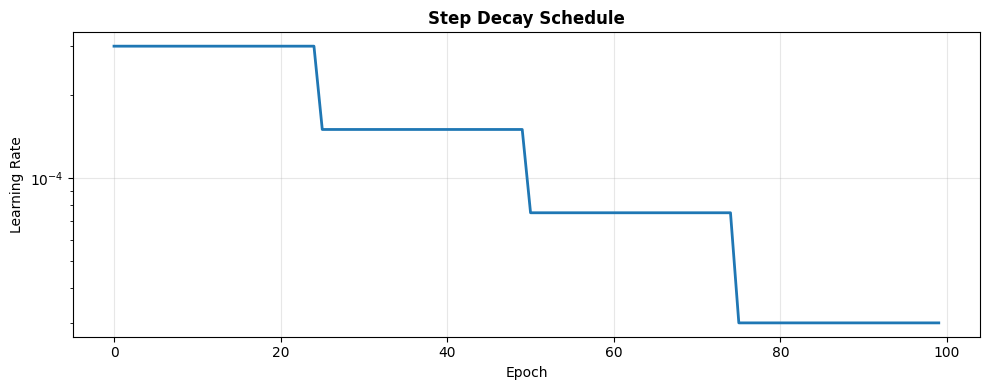

📈 LEARNING RATE SCHEDULE
  Epochs 0-24: 0.0003
  Epochs 25-49: 0.00015
  Epochs 50-74: 7.5e-05
  Epochs 75+: 2.9999999999999997e-05


In [ ]:
def step_decay_schedule(epoch, lr):
    """
    Step decay - proven to work well.
    Drop LR by 50% every 25 epochs.
    """
    if epoch < 25:
        return INITIAL_LR
    elif epoch < 50:
        return INITIAL_LR * 0.5
    elif epoch < 75:
        return INITIAL_LR * 0.25
    else:
        return INITIAL_LR * 0.1

# Visualize
epochs_range = np.arange(100)
lrs = [step_decay_schedule(e, INITIAL_LR) for e in epochs_range]

plt.figure(figsize=(10, 4))
plt.plot(epochs_range, lrs, linewidth=2)
plt.xlabel('Epoch')
plt.ylabel('Learning Rate')
plt.title('Step Decay Schedule', fontweight='bold')
plt.grid(alpha=0.3)
plt.yscale('log')
plt.tight_layout()
plt.show()

print("📈 LEARNING RATE SCHEDULE")
print(f"  Epochs 0-24: {INITIAL_LR}")
print(f"  Epochs 25-49: {INITIAL_LR*0.5}")
print(f"  Epochs 50-74: {INITIAL_LR*0.25}")
print(f"  Epochs 75+: {INITIAL_LR*0.1}")

## 8. Compile

In [ ]:
optimizer = Adam(learning_rate=INITIAL_LR)

model.compile(
    optimizer=optimizer,
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print("✓ Model compiled")
print(f"  Optimizer: Adam (lr={INITIAL_LR})")
print("  Loss: Categorical Crossentropy")

✓ Model compiled
  Optimizer: Adam (lr=0.0003)
  Loss: Categorical Crossentropy


## 9. Callbacks

In [ ]:
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
output_dir = f'fer_balanced_{timestamp}'
os.makedirs(output_dir, exist_ok=True)

callbacks = [
    # Step decay scheduler
    LearningRateScheduler(step_decay_schedule, verbose=1),

    # Early stopping
    EarlyStopping(
        monitor='val_accuracy',
        patience=PATIENCE,
        restore_best_weights=True,
        mode='max',
        verbose=1
    ),

    # Reduce LR on plateau (backup)
    ReduceLROnPlateau(
        monitor='val_accuracy',
        factor=0.5,
        patience=8,
        min_lr=MIN_LR,
        mode='max',
        verbose=1
    ),

    # Save best
    ModelCheckpoint(
        f'{output_dir}/best_model.h5',
        monitor='val_accuracy',
        save_best_only=True,
        mode='max',
        verbose=1
    )
]

print("⚙️ CALLBACKS")
print(f"  ✓ Step Decay Schedule")
print(f"  ✓ Early Stopping (patience={PATIENCE})")
print(f"  ✓ ReduceLROnPlateau (backup)")
print(f"  ✓ ModelCheckpoint")
print(f"  ✓ Output: {output_dir}/")

⚙️ CALLBACKS
  ✓ Step Decay Schedule
  ✓ Early Stopping (patience=15)
  ✓ ReduceLROnPlateau (backup)
  ✓ ModelCheckpoint
  ✓ Output: fer_balanced_20260223_154528/


## 10. Sanity Check

In [ ]:
print("🔍 SANITY CHECKS")
print("="*50)

# Forward pass
test_pred = model.predict(X_train[:5], verbose=0)
print(f"✓ Forward pass: {test_pred.shape}")
print(f"  Output sums: {test_pred.sum(axis=1)}")

# Initial loss
init_loss, init_acc = model.evaluate(X_train[:100], y_train_cat[:100], verbose=0)
print(f"\n✓ Initial metrics:")
print(f"  Loss: {init_loss:.4f} (expect ~1.95)")
print(f"  Accuracy: {init_acc:.4f} (expect ~0.14)")

if init_loss > 3.0 or init_loss < 1.0:
    print("  ⚠️ Loss seems unusual - check data")
else:
    print("  ✓ Loss looks good!")

print("="*50)
print("✅ Ready to train!\n")

🔍 SANITY CHECKS
✓ Forward pass: (5, 7)
  Output sums: [0.99999994 0.9999999  0.99999994 1.         0.99999994]

✓ Initial metrics:
  Loss: 2.0802 (expect ~1.95)
  Accuracy: 0.0000 (expect ~0.14)
  ✓ Loss looks good!
✅ Ready to train!



## 11. TRAINING

In [ ]:
print("="*70)
print("🚀 STARTING TRAINING")
print("="*70)
print(f"Architecture: 64→128→256→512 (Balanced)")
print(f"Parameters: {params:,}")
print(f"Batch size: {BATCH_SIZE}")
print(f"Initial LR: {INITIAL_LR}")
print(f"Max epochs: {EPOCHS}")
print(f"Expected time: 35-50 minutes")
print("="*70 + "\n")

start_time = time.time()

history = model.fit(
    train_datagen.flow(X_train, y_train_cat, batch_size=BATCH_SIZE),
    steps_per_epoch=len(X_train) // BATCH_SIZE,
    epochs=EPOCHS,
    validation_data=(X_test, y_test_cat),
    class_weight=class_weights_dict,
    callbacks=callbacks,
    verbose=1
)

training_time = time.time() - start_time

print("\n" + "="*70)
print("✅ TRAINING COMPLETED")
print("="*70)
print(f"Time: {training_time/60:.1f} minutes")
print(f"Epochs: {len(history.history['accuracy'])}")
print("="*70)

🚀 STARTING TRAINING
Architecture: 64→128→256→512 (Balanced)
Parameters: 5,681,863
Batch size: 64
Initial LR: 0.0003
Max epochs: 100
Expected time: 35-50 minutes


Epoch 1: LearningRateScheduler setting learning rate to 0.0003.
Epoch 1/100
448/448 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step - accuracy: 0.1467 - loss: 2.5121
Epoch 1: val_accuracy improved from -inf to 0.02489, saving model to fer_balanced_20260223_154528/best_model.h5


448/448 ━━━━━━━━━━━━━━━━━━━━ 63s 94ms/step - accuracy: 0.1467 - loss: 2.5118 - val_accuracy: 0.0249 - val_loss: 2.1065 - learning_rate: 3.0000e-04

Epoch 2: LearningRateScheduler setting learning rate to 0.0003.
Epoch 2/100
  1/448 ━━━━━━━━━━━━━━━━━━━━ 21s 49ms/step - accuracy: 0.1406 - loss: 2.6110
Epoch 2: val_accuracy did not improve from 0.02489
448/448 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.1406 - loss: 2.6110 - val_accuracy: 0.0236 - val_loss: 2.1073 - learning_rate: 3.0000e-04

Epoch 3: LearningRateScheduler setting learning rate to 0.0003.
Epoch 3/100
448/448 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step - accuracy: 0.1559 - loss: 2.2365
Epoch 3: val_accuracy improved from 0.02489 to 0.10538, saving model to fer_balanced_20260223_154528/best_model.h5


448/448 ━━━━━━━━━━━━━━━━━━━━ 28s 62ms/step - accuracy: 0.1559 - loss: 2.2365 - val_accuracy: 0.1054 - val_loss: 2.0672 - learning_rate: 3.0000e-04

Epoch 4: LearningRateScheduler setting learning rate to 0.0003.
Epoch 4/100
  1/448 ━━━━━━━━━━━━━━━━━━━━ 22s 51ms/step - accuracy: 0.1562 - loss: 1.9008
Epoch 4: val_accuracy did not improve from 0.10538
448/448 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.1562 - loss: 1.9008 - val_accuracy: 0.1013 - val_loss: 2.0693 - learning_rate: 3.0000e-04

Epoch 5: LearningRateScheduler setting learning rate to 0.0003.
Epoch 5/100
448/448 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step - accuracy: 0.1849 - loss: 2.1048
Epoch 5: val_accuracy improved from 0.10538 to 0.21257, saving model to fer_balanced_20260223_154528/best_model.h5


448/448 ━━━━━━━━━━━━━━━━━━━━ 29s 64ms/step - accuracy: 0.1849 - loss: 2.1047 - val_accuracy: 0.2126 - val_loss: 2.0065 - learning_rate: 3.0000e-04

Epoch 6: LearningRateScheduler setting learning rate to 0.0003.
Epoch 6/100
  1/448 ━━━━━━━━━━━━━━━━━━━━ 22s 50ms/step - accuracy: 0.1562 - loss: 1.7472
Epoch 6: val_accuracy did not improve from 0.21257
448/448 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.1562 - loss: 1.7472 - val_accuracy: 0.2059 - val_loss: 2.0128 - learning_rate: 3.0000e-04

Epoch 7: LearningRateScheduler setting learning rate to 0.0003.
Epoch 7/100
448/448 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step - accuracy: 0.2076 - loss: 2.0432
Epoch 7: val_accuracy improved from 0.21257 to 0.23356, saving model to fer_balanced_20260223_154528/best_model.h5


448/448 ━━━━━━━━━━━━━━━━━━━━ 29s 64ms/step - accuracy: 0.2077 - loss: 2.0432 - val_accuracy: 0.2336 - val_loss: 1.9258 - learning_rate: 3.0000e-04

Epoch 8: LearningRateScheduler setting learning rate to 0.0003.
Epoch 8/100
  1/448 ━━━━━━━━━━━━━━━━━━━━ 21s 49ms/step - accuracy: 0.2812 - loss: 1.6516
Epoch 8: val_accuracy did not improve from 0.23356
448/448 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.2812 - loss: 1.6516 - val_accuracy: 0.2197 - val_loss: 1.9309 - learning_rate: 3.0000e-04

Epoch 9: LearningRateScheduler setting learning rate to 0.0003.
Epoch 9/100
448/448 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step - accuracy: 0.2468 - loss: 1.9348
Epoch 9: val_accuracy improved from 0.23356 to 0.34575, saving model to fer_balanced_20260223_154528/best_model.h5


...

448/448 ━━━━━━━━━━━━━━━━━━━━ 29s 64ms/step - accuracy: 0.6495 - loss: 0.9853 - val_accuracy: 0.6465 - val_loss: 1.0791 - learning_rate: 3.0000e-05

Epoch 82: LearningRateScheduler setting learning rate to 2.9999999999999997e-05.
Epoch 82/100
  1/448 ━━━━━━━━━━━━━━━━━━━━ 21s 49ms/step - accuracy: 0.6250 - loss: 0.9365
Epoch 82: val_accuracy did not improve from 0.64646
448/448 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.6250 - loss: 0.9365 - val_accuracy: 0.6458 - val_loss: 1.0795 - learning_rate: 3.0000e-05

Epoch 83: LearningRateScheduler setting learning rate to 2.9999999999999997e-05.
Epoch 83/100
448/448 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step - accuracy: 0.6544 - loss: 0.9905
Epoch 83: val_accuracy did not improve from 0.64646
448/448 ━━━━━━━━━━━━━━━━━━━━ 29s 64ms/step - accuracy: 0.6544 - loss: 0.9905 - val_accuracy: 0.6440 - val_loss: 1.0863 - learning_rate: 3.0000e-05

Epoch 84: LearningRateScheduler setting learning rate to 2.9999999999999997e-05.
Epoch 84/100
  1/448 ━━━━━━━━━━━

448/448 ━━━━━━━━━━━━━━━━━━━━ 39s 65ms/step - accuracy: 0.6496 - loss: 0.9784 - val_accuracy: 0.6484 - val_loss: 1.0779 - learning_rate: 3.0000e-05

Epoch 86: LearningRateScheduler setting learning rate to 2.9999999999999997e-05.
Epoch 86/100
  1/448 ━━━━━━━━━━━━━━━━━━━━ 22s 50ms/step - accuracy: 0.6562 - loss: 1.0189
Epoch 86: val_accuracy did not improve from 0.64841
448/448 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.6562 - loss: 1.0189 - val_accuracy: 0.6472 - val_loss: 1.0788 - learning_rate: 3.0000e-05

Epoch 87: LearningRateScheduler setting learning rate to 2.9999999999999997e-05.
Epoch 87/100
448/448 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step - accuracy: 0.6530 - loss: 0.9843
Epoch 87: val_accuracy did not improve from 0.64841
448/448 ━━━━━━━━━━━━━━━━━━━━ 29s 64ms/step - accuracy: 0.6530 - loss: 0.9843 - val_accuracy: 0.6422 - val_loss: 1.0836 - learning_rate: 3.0000e-05

Epoch 88: LearningRateScheduler setting learning rate to 2.9999999999999997e-05.
Epoch 88/100
  1/448 ━━━━━━━━━━━

448/448 ━━━━━━━━━━━━━━━━━━━━ 29s 64ms/step - accuracy: 0.6555 - loss: 0.9704 - val_accuracy: 0.6506 - val_loss: 1.0763 - learning_rate: 3.0000e-05

Epoch 92: LearningRateScheduler setting learning rate to 2.9999999999999997e-05.
Epoch 92/100
  1/448 ━━━━━━━━━━━━━━━━━━━━ 23s 52ms/step - accuracy: 0.7031 - loss: 0.9111
Epoch 92: val_accuracy improved from 0.65063 to 0.65147, saving model to fer_balanced_20260223_154528/best_model.h5


448/448 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.7031 - loss: 0.9111 - val_accuracy: 0.6515 - val_loss: 1.0759 - learning_rate: 3.0000e-05

Epoch 93: LearningRateScheduler setting learning rate to 2.9999999999999997e-05.
Epoch 93/100
448/448 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step - accuracy: 0.6578 - loss: 0.9630
Epoch 93: val_accuracy did not improve from 0.65147
448/448 ━━━━━━━━━━━━━━━━━━━━ 29s 64ms/step - accuracy: 0.6578 - loss: 0.9630 - val_accuracy: 0.6403 - val_loss: 1.0979 - learning_rate: 3.0000e-05

Epoch 94: LearningRateScheduler setting learning rate to 2.9999999999999997e-05.
Epoch 94/100
  1/448 ━━━━━━━━━━━━━━━━━━━━ 22s 50ms/step - accuracy: 0.5781 - loss: 1.2245
Epoch 94: val_accuracy did not improve from 0.65147
448/448 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.5781 - loss: 1.2245 - val_accuracy: 0.6410 - val_loss: 1.0980 - learning_rate: 3.0000e-05

Epoch 95: LearningRateScheduler setting learning rate to 2.9999999999999997e-05.
Epoch 95/100
448/448 ━━━━━━━━━━━━━

448/448 ━━━━━━━━━━━━━━━━━━━━ 29s 64ms/step - accuracy: 0.6672 - loss: 0.9410 - val_accuracy: 0.6580 - val_loss: 1.0549 - learning_rate: 3.0000e-05

Epoch 96: LearningRateScheduler setting learning rate to 2.9999999999999997e-05.
Epoch 96/100
  1/448 ━━━━━━━━━━━━━━━━━━━━ 22s 50ms/step - accuracy: 0.7656 - loss: 0.7293
Epoch 96: val_accuracy did not improve from 0.65800
448/448 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.7656 - loss: 0.7293 - val_accuracy: 0.6570 - val_loss: 1.0547 - learning_rate: 3.0000e-05

Epoch 97: LearningRateScheduler setting learning rate to 2.9999999999999997e-05.
Epoch 97/100
448/448 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step - accuracy: 0.6656 - loss: 0.9545
Epoch 97: val_accuracy did not improve from 0.65800
448/448 ━━━━━━━━━━━━━━━━━━━━ 29s 64ms/step - accuracy: 0.6656 - loss: 0.9545 - val_accuracy: 0.6363 - val_loss: 1.1059 - learning_rate: 3.0000e-05

Epoch 98: LearningRateScheduler setting learning rate to 2.9999999999999997e-05.
Epoch 98/100
  1/448 ━━━━━━━━━━━

## 12. Results

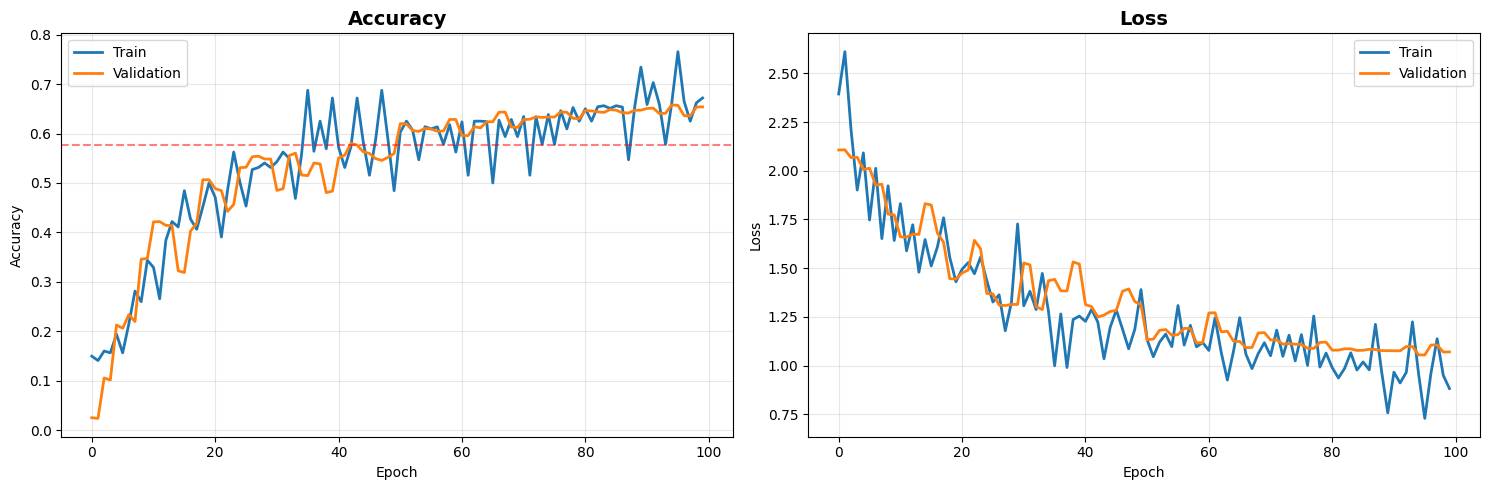


📊 RESULTS
Best val acc: 0.6580 (65.80%)
Best epoch: 95
Final train acc: 0.6719
Final val acc: 0.6540
Train-Val gap: 1.79%

vs Target (57.68%): +8.12%


In [ ]:
# Plot
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

axes[0].plot(history.history['accuracy'], label='Train', linewidth=2)
axes[0].plot(history.history['val_accuracy'], label='Validation', linewidth=2)
axes[0].set_title('Accuracy', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(alpha=0.3)
axes[0].axhline(0.5768, color='red', linestyle='--', alpha=0.5, label='Target (57.68%)')

axes[1].plot(history.history['loss'], label='Train', linewidth=2)
axes[1].plot(history.history['val_loss'], label='Validation', linewidth=2)
axes[1].set_title('Loss', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(f'{output_dir}/training_curves.png', dpi=150)
plt.show()

# Metrics
best_val_acc = max(history.history['val_accuracy'])
best_epoch = history.history['val_accuracy'].index(best_val_acc) + 1
final_train_acc = history.history['accuracy'][-1]
final_val_acc = history.history['val_accuracy'][-1]

print("\n📊 RESULTS")
print("="*50)
print(f"Best val acc: {best_val_acc:.4f} ({best_val_acc*100:.2f}%)")
print(f"Best epoch: {best_epoch}")
print(f"Final train acc: {final_train_acc:.4f}")
print(f"Final val acc: {final_val_acc:.4f}")
print(f"Train-Val gap: {(final_train_acc - final_val_acc)*100:.2f}%")
print(f"\nvs Target (57.68%): {(best_val_acc - 0.5768)*100:+.2f}%")
print("="*50)

## 13. Evaluation


Test accuracy: 0.6580 (65.80%)


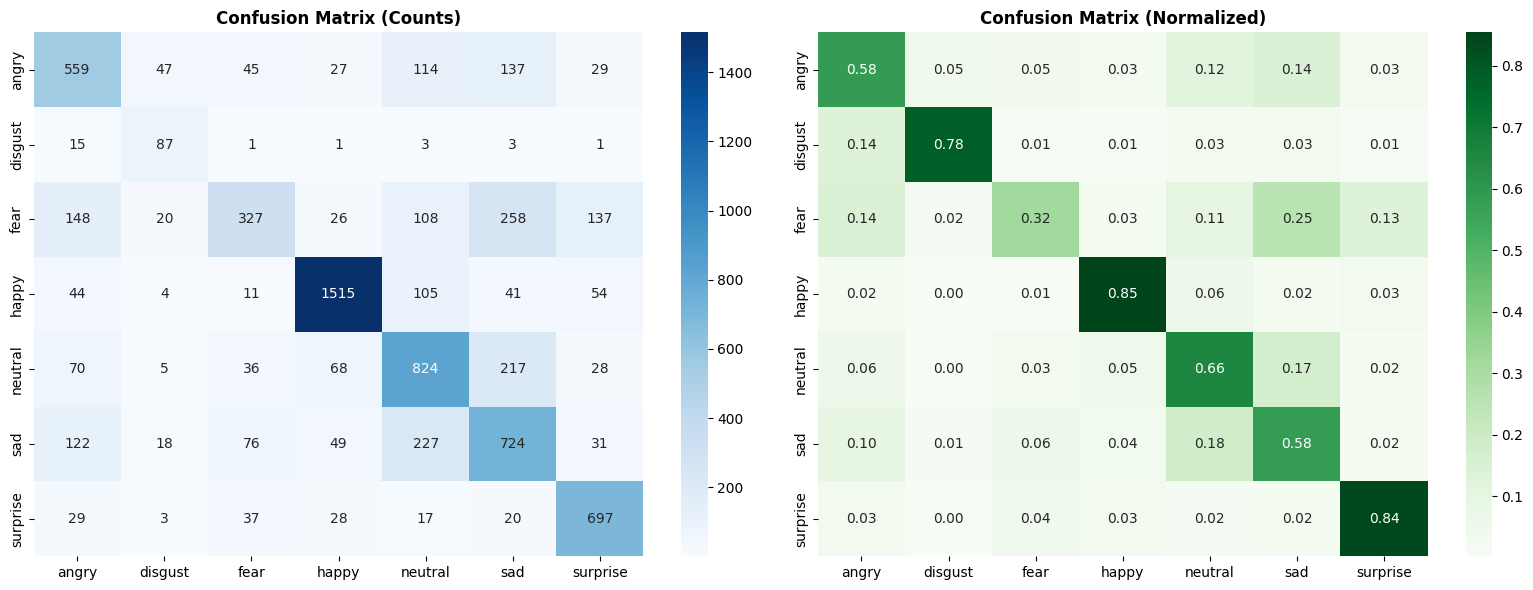


📋 CLASSIFICATION REPORT
              precision    recall  f1-score   support

       angry     0.5664    0.5835    0.5748       958
     disgust     0.4728    0.7838    0.5898       111
        fear     0.6135    0.3193    0.4200      1024
       happy     0.8839    0.8540    0.8687      1774
     neutral     0.5894    0.6603    0.6228      1248
         sad     0.5171    0.5806    0.5470      1247
    surprise     0.7134    0.8387    0.7710       831

    accuracy                         0.6580      7193
   macro avg     0.6224    0.6600    0.6277      7193
weighted avg     0.6624    0.6580    0.6517      7193



In [ ]:
# Load best
best_model = load_model(f'{output_dir}/best_model.h5')

# Evaluate
test_loss, test_acc = best_model.evaluate(X_test, y_test_cat, verbose=0)
print(f"\nTest accuracy: {test_acc:.4f} ({test_acc*100:.2f}%)")

# Predictions
y_pred_probs = best_model.predict(X_test, verbose=0)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = y_test

# Confusion matrix
cm = confusion_matrix(y_true, y_pred)
cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=EMOTIONS, yticklabels=EMOTIONS, ax=axes[0])
axes[0].set_title('Confusion Matrix (Counts)', fontweight='bold')

sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Greens',
            xticklabels=EMOTIONS, yticklabels=EMOTIONS, ax=axes[1])
axes[1].set_title('Confusion Matrix (Normalized)', fontweight='bold')

plt.tight_layout()
plt.savefig(f'{output_dir}/confusion_matrix.png', dpi=150)
plt.show()

# Report
print("\n📋 CLASSIFICATION REPORT")
print("="*70)
print(classification_report(y_true, y_pred, target_names=EMOTIONS, digits=4))
print("="*70)

## 14. Summary

In [ ]:
print("\n" + "="*70)
print("🎉 FINAL SUMMARY")
print("="*70)

print("\n📈 ACCURACY PROGRESSION:")
print(f"  Attempt 1 (too complex): 24.65%")
print(f"  Attempt 2 (too simple): 51.72%")
print(f"  Attempt 3 (balanced): {test_acc*100:.2f}%")
print(f"  Target: 57.68%")
print(f"  Difference: {(test_acc - 0.5768)*100:+.2f}% points")

print("\n🏗️ ARCHITECTURE:")
print("  Filters: 64 → 128 → 256 → 512")
print("  Dense: 512 → 256")
print(f"  Parameters: {params:,}")
print(f"  Dropout: {DROPOUT_CONV} (conv), {DROPOUT_DENSE} (dense)")

print("\n⚙️ TRAINING:")
print(f"  Time: {training_time/60:.1f} minutes")
print(f"  Epochs: {len(history.history['accuracy'])}")
print(f"  Best epoch: {best_epoch}")
print(f"  Learning rate: Step decay")

if test_acc > 0.60:
    print("\n✅ SUCCESS! Model performing well!")
elif test_acc > 0.55:
    print("\n⚠️ ACCEPTABLE - Close to target")
else:
    print("\n❌ NEEDS MORE WORK")

print("="*70)


🎉 FINAL SUMMARY

📈 ACCURACY PROGRESSION:
  Attempt 1 (too complex): 24.65%
  Attempt 2 (too simple): 51.72%
  Attempt 3 (balanced): 65.80%
  Target: 57.68%
  Difference: +8.12% points

🏗️ ARCHITECTURE:
  Filters: 64 → 128 → 256 → 512
  Dense: 512 → 256
  Parameters: 5,681,863
  Dropout: 0.25 (conv), 0.5 (dense)

⚙️ TRAINING:
  Time: 27.0 minutes
  Epochs: 100
  Best epoch: 95
  Learning rate: Step decay

✅ SUCCESS! Model performing well!
